In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

### Load data

In [2]:
cm = pd.read_csv('Breast_GSE45827.csv')

In [3]:
y = cm["type"].astype(str)
X = cm.drop(columns=["samples", "type"])

In [4]:
# ── 2. Train/Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [5]:
# ── 3. Encode Labels ──────────────────────────────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [6]:
# ── 4. Scale ──────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [7]:
# ── 5. Variance Filter ────────────────────────────────────────
var_filter = VarianceThreshold(threshold=0.01)
X_train_var = var_filter.fit_transform(X_train_scaled)
X_test_var  = var_filter.transform(X_test_scaled)
print("After variance filter:", X_train_var.shape)

After variance filter: (105, 54675)


## This is the answer to the challenge

In [ ]:
# ── 6. PCA + XGBoost for 30, 40, 50 components ───────────────
results = []
 
for n_components in [30, 40, 50]:
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_var)
    X_test_pca  = pca.transform(X_test_var)

    explained = pca.explained_variance_ratio_.sum()
    print(f"\n--- PCA with {n_components} components ---")
    print(f"  Variance explained: {explained*100:.1f}%")
    print(f"  X_train shape: {X_train_pca.shape}")

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
    model.fit(X_train_pca, y_train_enc)

      # --- Evaluate ---

    y_pred_enc = model.predict(X_test_pca)
    y_pred     = le.inverse_transform(y_pred_enc)
    acc        = accuracy_score(y_test, y_pred)
 
    print(f"  Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, digits=3))
 
    results.append({
        "PCA Components": n_components,
        "Variance Explained (%)": round(explained * 100, 1),
        "Accuracy": round(acc, 4)
    })


--- PCA with 30 components ---
  Variance explained: 64.9%
  X_train shape: (105, 30)
  Accuracy: 0.8913
              precision    recall  f1-score   support

         HER      1.000     0.778     0.875         9
       basal      0.929     1.000     0.963        13
   cell_line      1.000     1.000     1.000         4
   luminal_A      0.800     0.889     0.842         9
   luminal_B      0.800     0.889     0.842         9
      normal      1.000     0.500     0.667         2

    accuracy                          0.891        46
   macro avg      0.921     0.843     0.865        46
weighted avg      0.902     0.891     0.889        46


--- PCA with 40 components ---
  Variance explained: 71.8%
  X_train shape: (105, 40)
  Accuracy: 0.8913
              precision    recall  f1-score   support

         HER      1.000     0.778     0.875         9
       basal      0.929     1.000     0.963        13
   cell_line      1.000     1.000     1.000         4
   luminal_A      0.800     

In [9]:
# ── 7. Compare Results ────────────────────────────────────────
results_df = pd.DataFrame(results)
print("\n=== COMPARISON TABLE ===")
print(results_df.to_string(index=False))
 
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest result → PCA with {int(best['PCA Components'])} components "
      f"(Accuracy: {best['Accuracy']}, "
      f"Variance explained: {best['Variance Explained (%)']}%)")


=== COMPARISON TABLE ===
 PCA Components  Variance Explained (%)  Accuracy
             30                    64.9    0.8913
             40                    71.8    0.8913
             50                    77.7    0.8913

Best result → PCA with 30 components (Accuracy: 0.8913, Variance explained: 64.9%)


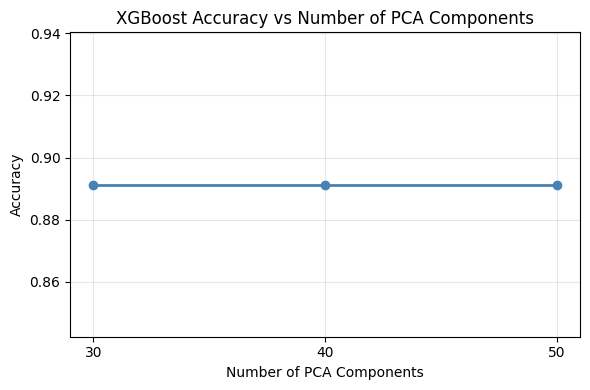

In [10]:
# ── 8. Plot Accuracy vs Components ───────────────────────────
plt.figure(figsize=(6, 4))
plt.plot(results_df['PCA Components'], results_df['Accuracy'],
         marker='o', linewidth=2, color='steelblue')
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.title("XGBoost Accuracy vs Number of PCA Components")
plt.xticks([30, 40, 50])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()